In [20]:
# Listing 1

import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the penguin dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' species
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy() # Make a copy to avoide the warning

# Initialize the LabelEncoder
le = LabelEncoder()

# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DtaFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X = df_filtered.drop(['class_encoded'], axis=1) 


       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]


In [29]:
# Listing 2 (Ammended)

X = df_filtered.drop(['class_encoded', 'species', 'island', 'sex'], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

# Train the logstic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='saga', max_iter=1000)
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print(logreg.coef_, logreg.intercept_)

Accuracy:  0.627906976744186
[[ 2.68603244e-02 -1.48991339e-03  7.02057606e-05 -5.13623806e-04]] [-0.00011387]


c:\Users\mufte\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [23]:
# Listing 2 (Ammended)

X = df_filtered.drop(['class_encoded', 'species', 'island', 'sex'], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logstic regression model. Here we are using liblinear to learn weights.
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print(logreg.coef_, logreg.intercept_)

Accuracy:  1.0
[[ 1.67821215 -1.40016667 -0.16592212 -0.00432862]] [-0.07906013]


c:\Users\mufte\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


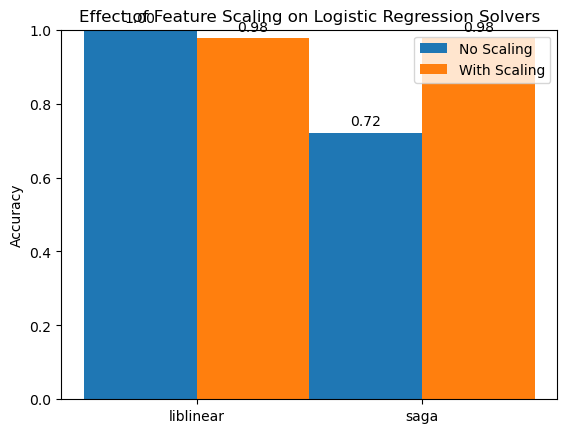

In [31]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- Load and preprocess the dataset ---
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' species
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()

# Encode the species column
le = LabelEncoder()
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Prepare features (drop non-numeric columns)
X = df_filtered.drop(['class_encoded', 'species', 'island', 'sex'], axis=1)
y = df_filtered['class_encoded']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Define solvers to compare ---
solvers = ['liblinear', 'saga']
results = {'No Scaling': [], 'With Scaling': []}

# --- Without feature scaling ---
for solver in solvers:
    logreg = LogisticRegression(solver=solver, max_iter=5000, random_state=42)
    logreg.fit(X_train, y_train)
    y_pred = logreg.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results['No Scaling'].append(acc)

# --- With feature scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for solver in solvers:
    logreg = LogisticRegression(solver=solver, max_iter=5000, random_state=42)
    logreg.fit(X_train_scaled, y_train)
    y_pred = logreg.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results['With Scaling'].append(acc)

# --- Visualization ---
x = range(len(solvers))
width = 0.5

fig, ax = plt.subplots()
rects1 = ax.bar([i - width/2 for i in x], results['No Scaling'], width, label='No Scaling')
rects2 = ax.bar([i + width/2 for i in x], results['With Scaling'], width, label='With Scaling')

ax.set_ylabel('Accuracy')
ax.set_title('Effect of Feature Scaling on Logistic Regression Solvers')
ax.set_xticks(x)
ax.set_xticklabels(solvers)
ax.set_ylim(0, 1)
ax.legend()

# Add accuracy labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3), textcoords="offset points", ha='center', va='bottom')

plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]

X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

Iteration 1: Loss = 0.6715
Iteration 2: Loss = 0.3505
Iteration 3: Loss = 0.2431
Iteration 4: Loss = 0.1895
Iteration 5: Loss = 0.1568
Iteration 6: Loss = 0.1345
Iteration 7: Loss = 0.1182
Iteration 8: Loss = 0.1058
Iteration 9: Loss = 0.0959
Iteration 10: Loss = 0.0878
Iteration 11: Loss = 0.0811
Iteration 12: Loss = 0.0754
Iteration 13: Loss = 0.0706
Iteration 14: Loss = 0.0663
Iteration 15: Loss = 0.0626
Iteration 16: Loss = 0.0593
Iteration 17: Loss = 0.0564
Iteration 18: Loss = 0.0538
Iteration 19: Loss = 0.0514
Iteration 20: Loss = 0.0492


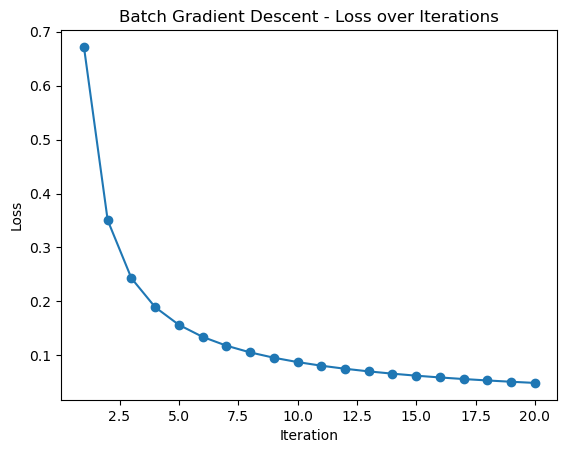

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# -----------------------------
# Step 1: Data Generation
# -----------------------------
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]

X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

# Add intercept term (bias) by appending ones
X = np.c_[np.ones(X.shape[0]), X]  # shape: (2000, 3)

# -----------------------------
# Step 2: Sigmoid Function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Step 3: Gradient Descent
# -----------------------------
def batch_gradient_descent(X, y, lr=0.01, iterations=20):
    n_samples, n_features = X.shape
    # Random weight initialization (small random numbers)
    weights = np.random.randn(n_features) * 0.01
    losses = []

    for i in range(iterations):
        # Predictions
        linear_model = np.dot(X, weights)
        y_pred = sigmoid(linear_model)

        # Compute loss (Binary Cross-Entropy)
        loss = - (1/n_samples) * np.sum(
            y * np.log(y_pred + 1e-9) + (1 - y) * np.log(1 - y_pred + 1e-9)
        )
        losses.append(loss)

        # Gradient
        gradient = (1/n_samples) * np.dot(X.T, (y_pred - y))

        # Update weights
        weights -= lr * gradient

        print(f"Iteration {i+1}: Loss = {loss:.4f}")

    return weights, losses

# -----------------------------
# Step 4: Run BGD
# -----------------------------
weights, losses = batch_gradient_descent(X, y, lr=0.1, iterations=20)

# -----------------------------
# Step 5: Plot Loss Curve
# -----------------------------
plt.plot(range(1, 21), losses, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent - Loss over Iterations")
plt.show()


Iteration 1: Loss = 0.6715
Iteration 2: Loss = 0.1450
Iteration 3: Loss = 0.0527
Iteration 4: Loss = 0.0203
Iteration 5: Loss = 0.0080
Iteration 6: Loss = 0.0032
Iteration 7: Loss = 0.0013
Iteration 8: Loss = 0.0005
Iteration 9: Loss = 0.0002
Iteration 10: Loss = 0.0001
Iteration 11: Loss = 0.0000
Iteration 12: Loss = 0.0000
Iteration 13: Loss = 0.0000
Iteration 14: Loss = 0.0000
Iteration 15: Loss = 0.0000
Iteration 16: Loss = 0.0000
Iteration 17: Loss = 0.0000
Iteration 18: Loss = 0.0000
Iteration 19: Loss = 0.0000
Iteration 20: Loss = 0.0000


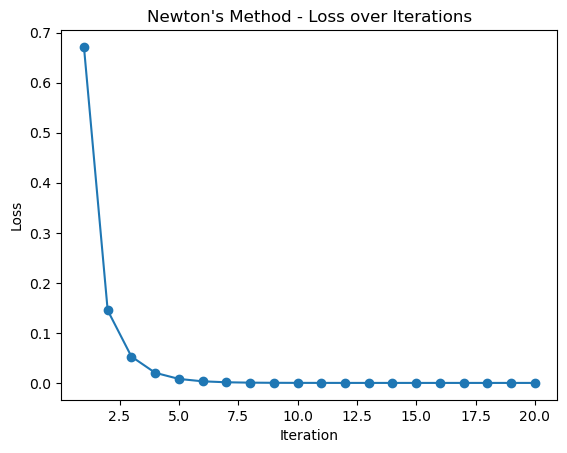

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# -----------------------------
# Step 1: Data Generation
# -----------------------------
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

# Add intercept term (bias)
X = np.c_[np.ones(X.shape[0]), X]

# -----------------------------
# Step 2: Sigmoid Function
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Step 3: Newton's Method
# -----------------------------
def newtons_method(X, y, iterations=20):
    n_samples, n_features = X.shape
    # Initialize weights to small random values
    weights = np.random.randn(n_features) * 0.01
    losses = []

    for i in range(iterations):
        # Predictions
        y_pred = sigmoid(np.dot(X, weights))

        # Loss (Binary Cross-Entropy)
        loss = - (1/n_samples) * np.sum(
            y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9)
        )
        losses.append(loss)

        # Gradient
        gradient = (1/n_samples) * np.dot(X.T, (y_pred - y))

        # Hessian
        R = np.diag((y_pred * (1 - y_pred)))
        H = (1/n_samples) * np.dot(X.T, np.dot(R, X))

        # Update rule: w := w - H^{-1} g
        try:
            H_inv = np.linalg.inv(H)
            weights -= np.dot(H_inv, gradient)
        except np.linalg.LinAlgError:
            print("Hessian is singular, stopping early.")
            break

        print(f"Iteration {i+1}: Loss = {loss:.4f}")

    return weights, losses

# -----------------------------
# Step 4: Run Newton's Method
# -----------------------------
weights, losses = newtons_method(X, y, iterations=20)

# -----------------------------
# Step 5: Plot Loss Curve
# -----------------------------
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Newton's Method - Loss over Iterations")
plt.show()


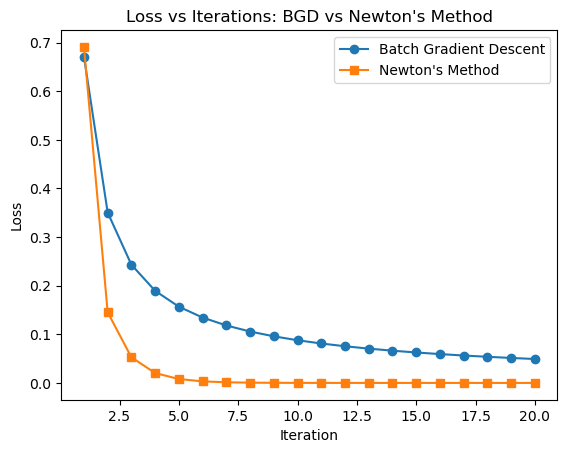

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# -----------------------------
# Data Generation
# -----------------------------
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

# Add intercept term
X = np.c_[np.ones(X.shape[0]), X]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# Batch Gradient Descent
# -----------------------------
def batch_gradient_descent(X, y, lr=0.1, iterations=20):
    n_samples, n_features = X.shape
    weights = np.random.randn(n_features) * 0.01
    losses = []
    for i in range(iterations):
        y_pred = sigmoid(np.dot(X, weights))
        loss = - (1/n_samples) * np.sum(
            y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9)
        )
        gradient = (1/n_samples) * np.dot(X.T, (y_pred - y))
        weights -= lr * gradient
        losses.append(loss)
    return losses

# -----------------------------
# Newton's Method
# -----------------------------
def newtons_method(X, y, iterations=20):
    n_samples, n_features = X.shape
    weights = np.random.randn(n_features) * 0.01
    losses = []
    for i in range(iterations):
        y_pred = sigmoid(np.dot(X, weights))
        loss = - (1/n_samples) * np.sum(
            y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9)
        )
        gradient = (1/n_samples) * np.dot(X.T, (y_pred - y))
        R = np.diag(y_pred * (1 - y_pred))
        H = (1/n_samples) * np.dot(X.T, np.dot(R, X))
        weights -= np.linalg.inv(H).dot(gradient)
        losses.append(loss)
    return losses

# -----------------------------
# Run Both Methods
# -----------------------------
bgd_losses = batch_gradient_descent(X, y, lr=0.1, iterations=20)
newton_losses = newtons_method(X, y, iterations=20)

# -----------------------------
# Plot Comparison
# -----------------------------
plt.plot(range(1, 21), bgd_losses, marker='o', label="Batch Gradient Descent")
plt.plot(range(1, 21), newton_losses, marker='s', label="Newton's Method")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iterations: BGD vs Newton's Method")
plt.legend()
plt.show()


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(0)
centers = [[2, 2], [5, 1.5]]

X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)